In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/processed/pharma_sales_cleaned.csv')

In [3]:
#Total Revenue
total_revenue = df['revenue'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $4,127,654,676.28


In [4]:
#Total Units Sold
total_units = df['units_sold'].sum()
print(f"Total Units Sold: {total_units:,}")

Total Units Sold: 78,534,584


In [5]:
#Unique Regions
df['region'].nunique()

8

In [6]:
#Unique Countries
df['country'].nunique()

19

In [7]:
#Unique Medicine Categories
df['category'].nunique()

5

In [8]:
#Revenue by Region
region_revenue = (
    df.groupby('region')['revenue']
    .sum()
    .sort_values(ascending=False)
)

print(region_revenue)

region
East Asia        5.192713e+08
South America    5.188874e+08
Europe           5.163563e+08
Middle East      5.156810e+08
Oceania          5.155757e+08
North America    5.151863e+08
South Asia       5.138564e+08
Africa           5.128403e+08
Name: revenue, dtype: float64


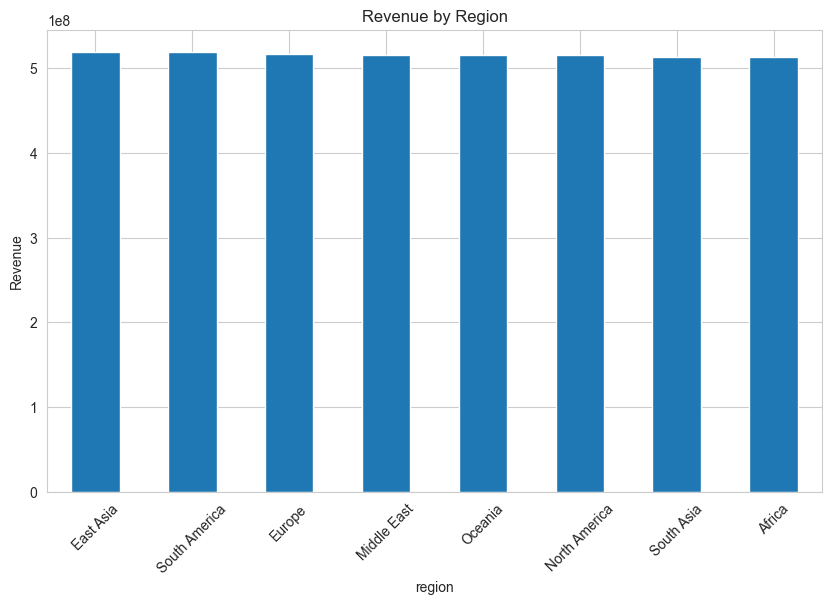

In [9]:
plt.figure(figsize=(10,6))

region_revenue.plot(kind='bar')

plt.title('Revenue by Region')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

In [10]:
#Top Countries by Revenue
country_revenue = (
    df.groupby('country')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(country_revenue)

country
Brazil          2.640359e+08
UAE             2.598402e+08
Nigeria         2.589336e+08
Canada          2.583560e+08
Australia       2.577989e+08
New Zealand     2.577768e+08
USA             2.568303e+08
Saudi Arabia    2.558409e+08
Argentina       2.548515e+08
Kenya           2.539067e+08
Name: revenue, dtype: float64


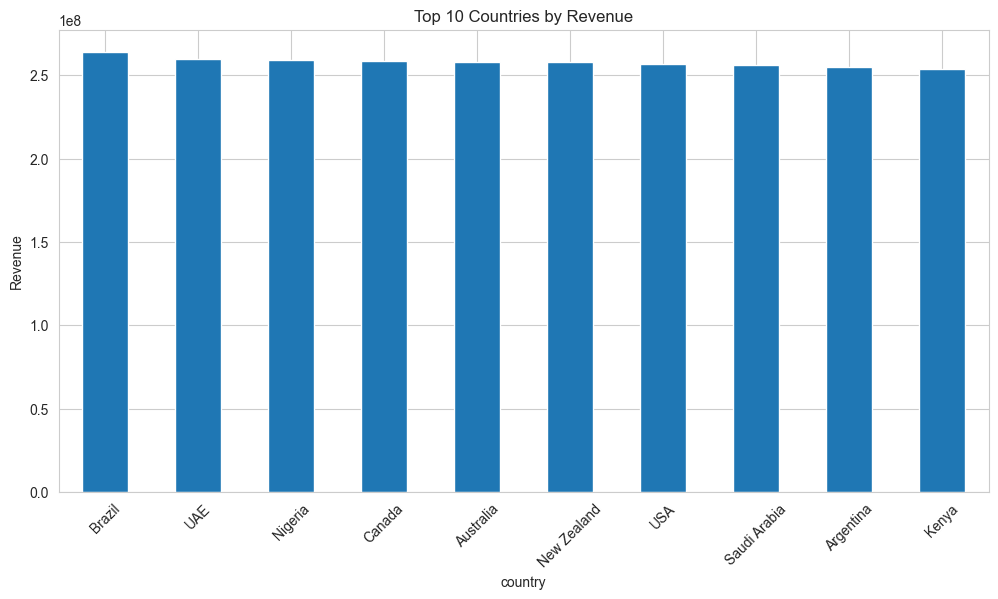

In [11]:
plt.figure(figsize=(12,6))

country_revenue.plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

In [12]:
#Category Analysis
category_revenue = (
    df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

category
Antipyretic    8.295979e+08
Cough_Cold     8.276622e+08
Antibiotic     8.265009e+08
Vitamin        8.225529e+08
Chronic        8.213407e+08
Name: revenue, dtype: float64


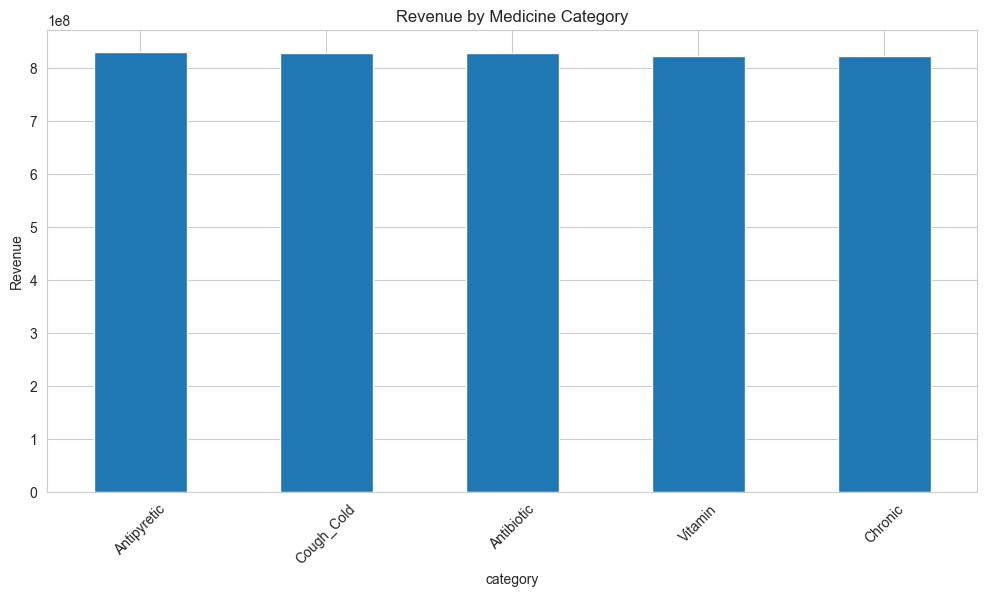

In [13]:
plt.figure(figsize=(12,6))

category_revenue.plot(kind='bar')

plt.title('Revenue by Medicine Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

In [14]:
#COVID Impact Analysis
covid_analysis = (
    df.groupby('covid_flag')['revenue']
    .mean()
)

print(covid_analysis)

covid_flag
0    19553.719633
1    31501.640314
Name: revenue, dtype: float64


In [15]:
#Monthly Revenue Trend
monthly_revenue = (
    df.groupby(['year', 'month'])['revenue']
    .sum()
    .reset_index()
)

monthly_revenue['year_month'] = (
    monthly_revenue['year'].astype(str)
    + '-'
    + monthly_revenue['month'].astype(str)
)

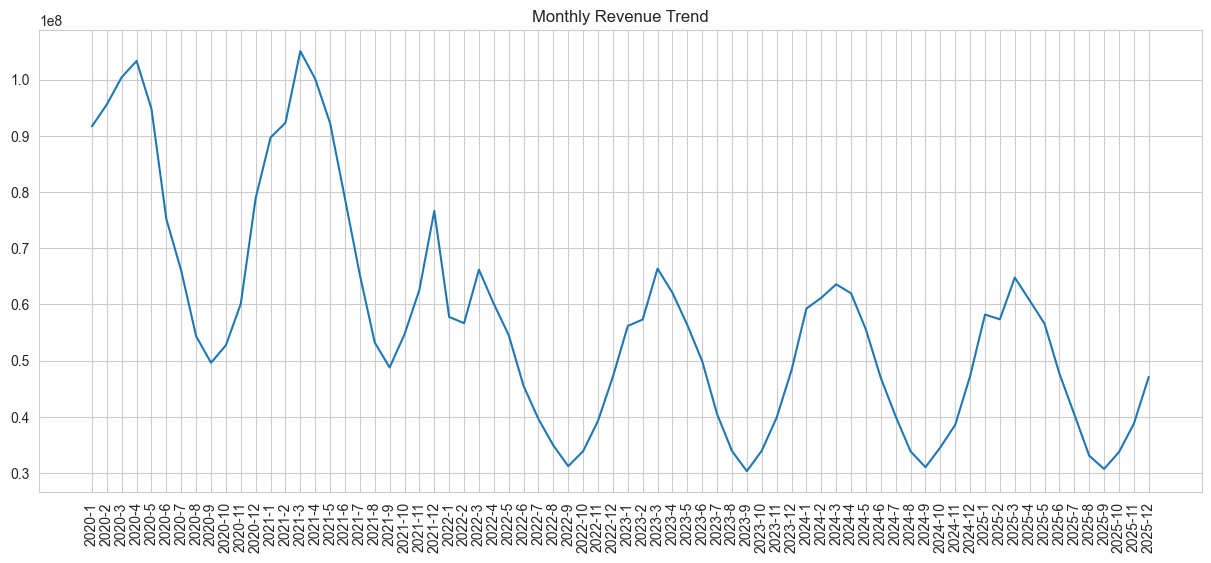

In [16]:
plt.figure(figsize=(15,6))

plt.plot(monthly_revenue['year_month'],
         monthly_revenue['revenue'])

plt.title('Monthly Revenue Trend')
plt.xticks(rotation=90)

plt.show()

In [17]:
#Yearly Revenue Trend
yearly_revenue = (
    df.groupby('year')['revenue']
    .sum()
)

yearly_revenue

year
2020    9.227561e+08
2021    9.194598e+08
2022    5.669810e+08
2023    5.752003e+08
2024    5.739594e+08
2025    5.692981e+08
Name: revenue, dtype: float64

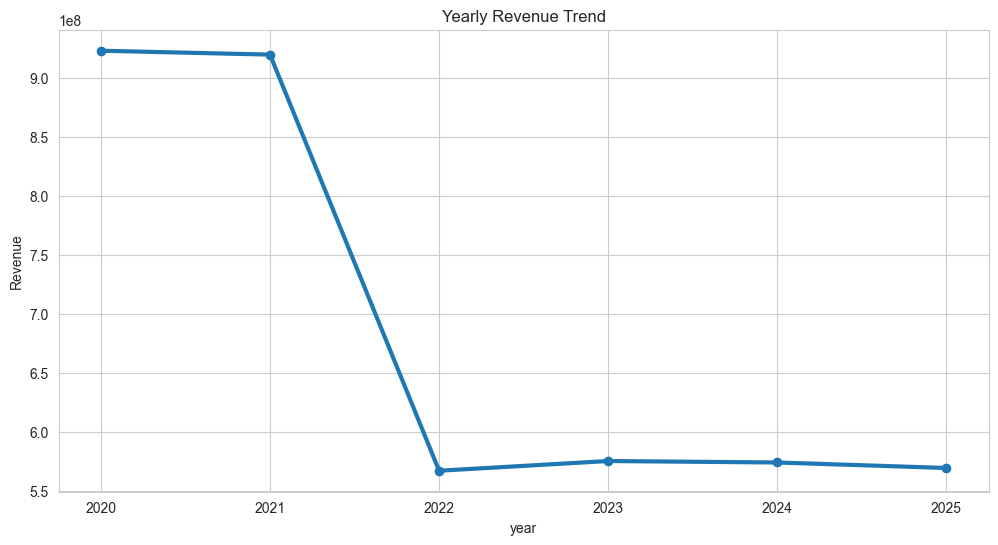

In [18]:
yearly_revenue.plot(
    kind='line',
    marker='o',
    linewidth=3
)

plt.title('Yearly Revenue Trend')
plt.ylabel('Revenue')

plt.show()

In [19]:
#Age Group Analysis
age_group_revenue = (
    df.groupby('age_group')['revenue']
    .sum()
    .sort_values(ascending=False)
)

age_group_revenue

age_group
46-65    8.390968e+08
65+      8.274585e+08
0-12     8.219388e+08
26-45    8.207466e+08
13-25    8.184140e+08
Name: revenue, dtype: float64

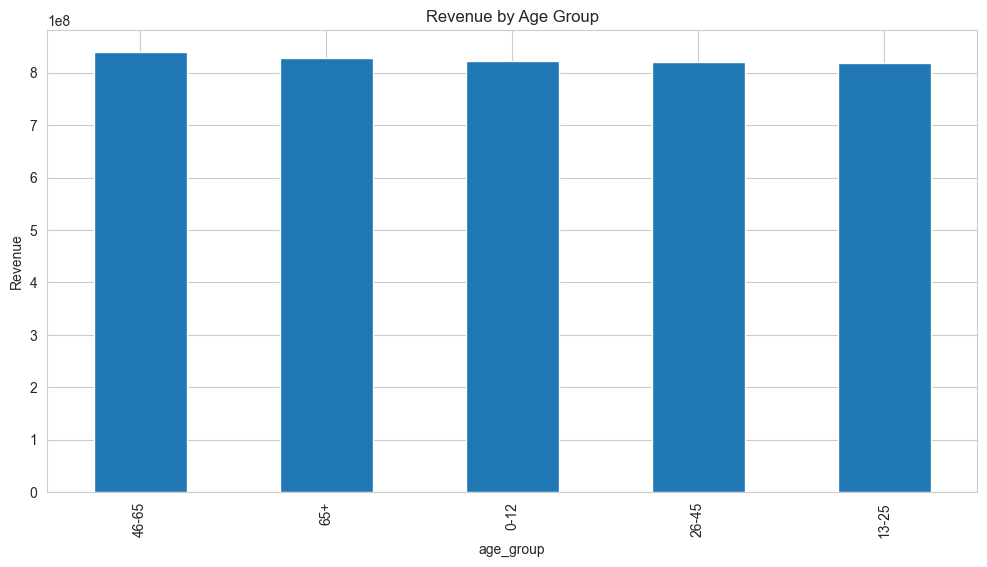

In [20]:
age_group_revenue.plot(kind='bar')

plt.title('Revenue by Age Group')
plt.ylabel('Revenue')

plt.show()

In [21]:
#Top Medicines
top_medicines = (
    df.groupby('medicine')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_medicines

medicine
Paracetamol     4.171531e+08
Azithromycin    4.167800e+08
Cough Syrup     4.159312e+08
Multivitamin    4.139161e+08
Metformin       4.125262e+08
Ibuprofen       4.124448e+08
Cetirizine      4.117310e+08
Amoxicillin     4.097209e+08
Amlodipine      4.088145e+08
Vitamin C       4.086368e+08
Name: revenue, dtype: float64

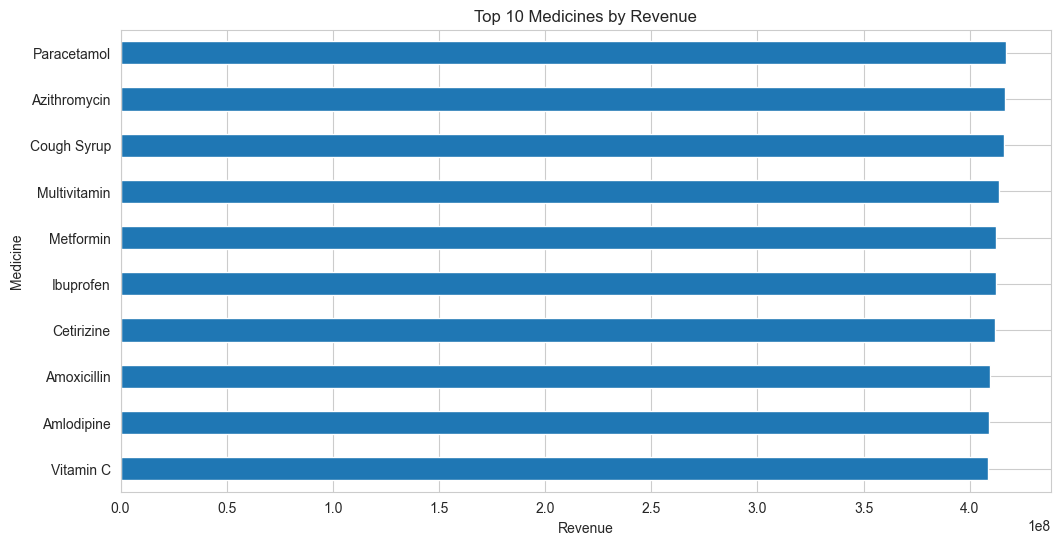

In [22]:
plt.figure(figsize=(12,6))

top_medicines.plot(
    kind='barh'
)

plt.title('Top 10 Medicines by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Medicine')

plt.gca().invert_yaxis()

plt.show()

In [23]:
#Inventory Risk Analysis
low_stock = df[df['stock_level'] < 100]

In [24]:
low_stock['category'].value_counts()

category
Vitamin        32
Chronic        30
Cough_Cold     28
Antipyretic    26
Antibiotic     22
Name: count, dtype: int64

In [26]:
#Expiry Risk
def expiry_risk_level(days):
    
    if days <= 30:
        return 'High Risk'
    
    elif days <= 90:
        return 'Medium Risk'
    
    else:
        return 'Low Risk'

df['expiry_risk'] = df['expiry_days_remaining'].apply(expiry_risk_level)

In [27]:
expiry_distribution = (
    df['expiry_risk']
    .value_counts()
)

print(expiry_distribution)

expiry_risk
Low Risk       159526
Medium Risk     15605
High Risk         229
Name: count, dtype: int64


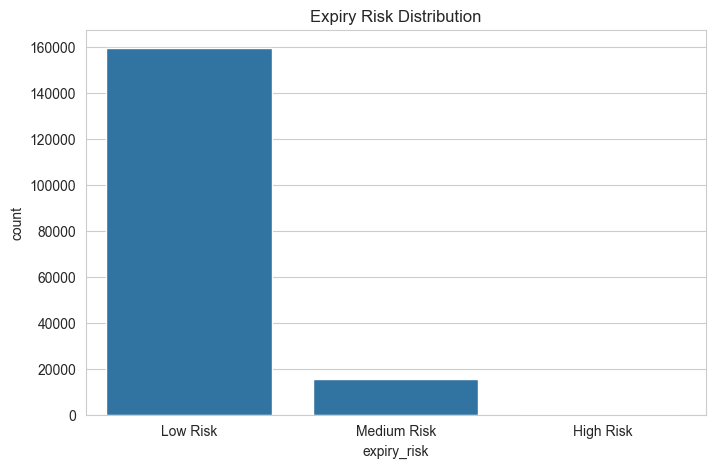

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='expiry_risk'
)

plt.title('Expiry Risk Distribution')

plt.show()

In [29]:
high_risk_expiry = df[df['expiry_risk'] == 'High Risk']

category_expiry = (
    high_risk_expiry.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
)

category_expiry

category
Antibiotic     1412829.84
Vitamin        1223336.88
Chronic        1010155.48
Antipyretic    1004370.58
Cough_Cold      907446.94
Name: revenue, dtype: float64

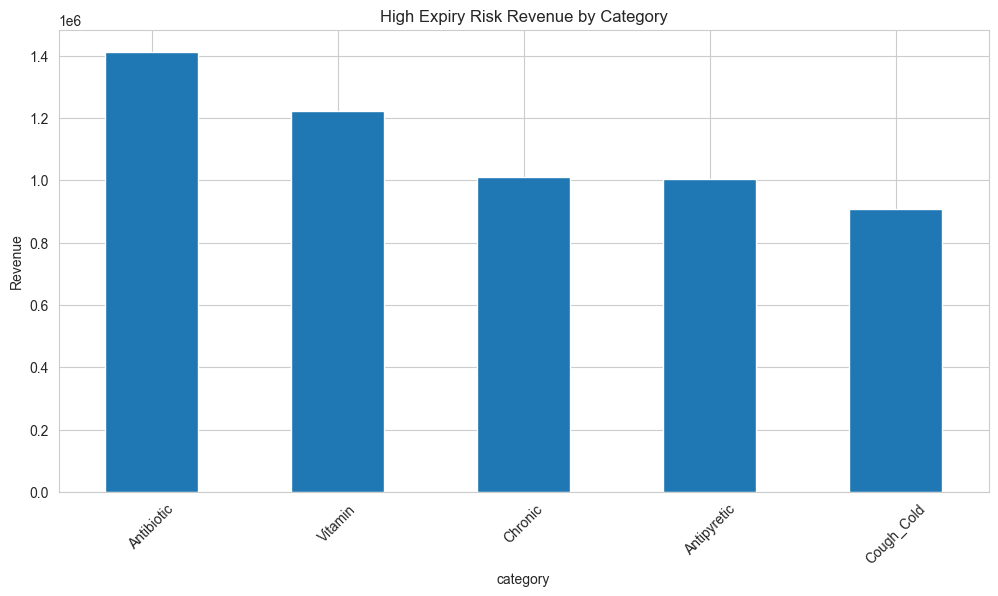

In [30]:
plt.figure(figsize=(12,6))

category_expiry.plot(
    kind='bar'
)

plt.title('High Expiry Risk Revenue by Category')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()